# Transfer Learning vs. Training from Scratch (Data Scarcity)

## Hypothesis
- **Transfer Learning** (pre-trained ResNet18): >80% accuracy with only 50 training images
- **From Scratch** (random weights): ~50% accuracy or severe overfitting

This notebook presents the full experiment: data exploration, training results, evaluation metrics, and Grad-CAM visualizations.

## 1. Dataset Exploration

device: cpu
[data] saved C:\Users\anton\PycharmProjects\xray-classifier\outputs\class_distribution.png


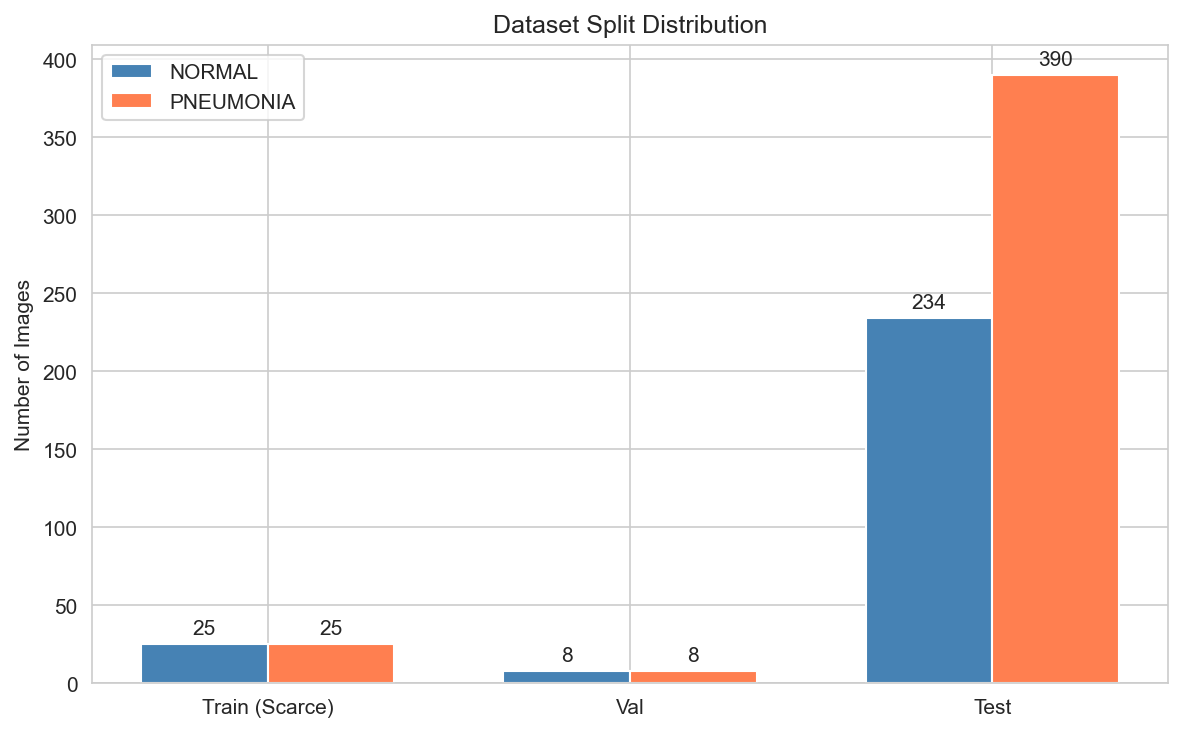

[data] saved C:\Users\anton\PycharmProjects\xray-classifier\outputs\augmented_samples.png


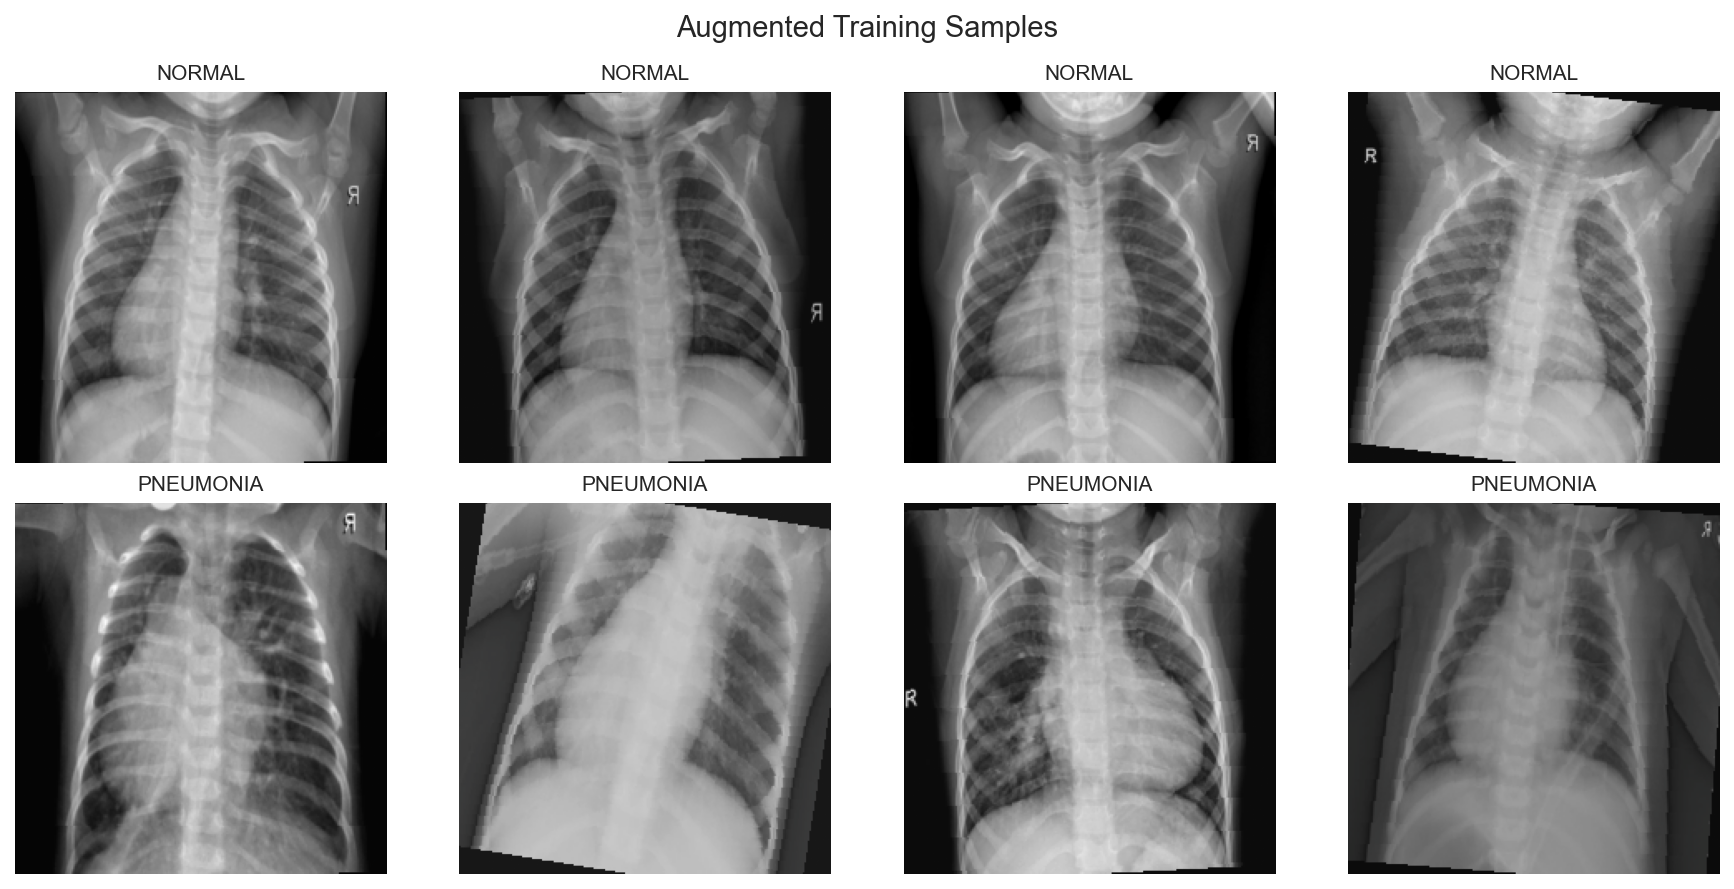

In [ ]:
import sys
import json
from pathlib import Path

import pandas as pd
import torch
from IPython.display import Image, display

ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))

OUTPUTS     = ROOT / "outputs"
CHECKPOINTS = ROOT / "checkpoints"
OUTPUTS.mkdir(exist_ok=True)

from src.data import (
    CLASSES,
    get_loaders, plot_augmented_samples, plot_class_distribution,
)
from src.models import get_model, count_params
from src.evaluate import (
    load_model, get_predictions, compute_metrics, compute_val_stats,
    plot_confusion_matrix, plot_learning_curves, plot_grad_cam,
    plot_roc_curves, plot_comparison_table,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

plot_class_distribution()
display(Image(str(OUTPUTS / "class_distribution.png"), width=680))

plot_augmented_samples()
display(Image(str(OUTPUTS / "augmented_samples.png"), width=780))

## 2. Model Architecture Comparison

In [2]:

rows = []
for name in ("pretrained", "scratch"):
    m = get_model(name, device)
    c = count_params(m)
    rows.append({
        "model":     name,
        "trainable": c["trainable"],
        "frozen":    c["total"] - c["trainable"],
        "total":     c["total"],
    })

df = pd.DataFrame(rows).set_index("model")
display(df.style.format("{:,}"))

print(
    "\nPretrained: ImageNet backbone frozen — only the FC head (512 → 2) is trained."
    "\nScratch:    all layers trained from random init."
)


,trainable,frozen,total
model,,,
pretrained,"1,026","11,176,512","11,177,538"
scratch,"11,177,538",0,"11,177,538"



Pretrained: ImageNet backbone frozen — only the FC head (512 → 2) is trained.
Scratch:    all layers trained from random init.


## 3. Training Results

pretrained    best val_acc = 0.8750  (epoch 14/30)
scratch       best val_acc = 0.8125  (epoch 11/30)



[eval] saved C:\Users\anton\PycharmProjects\xray-classifier\outputs\pretrained_learning_curves.png


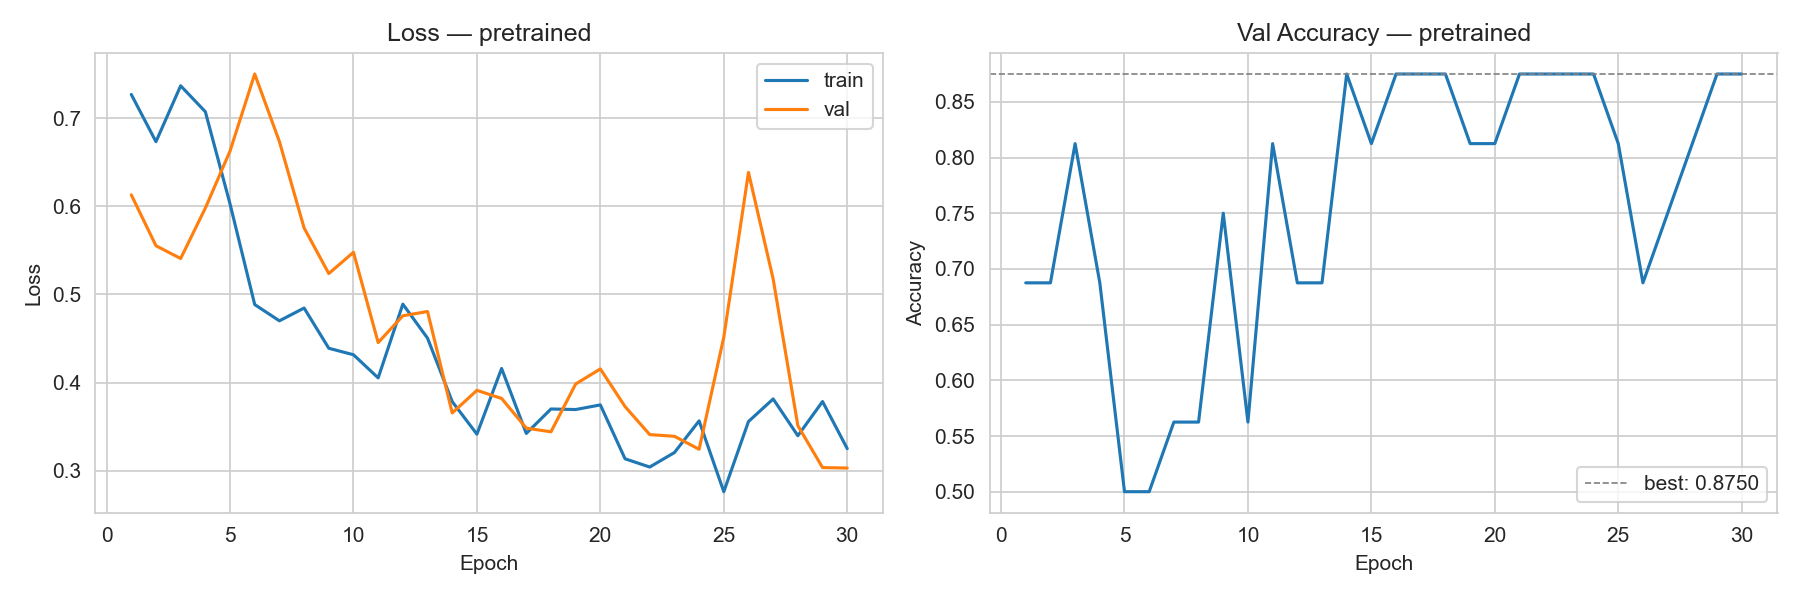

[eval] saved C:\Users\anton\PycharmProjects\xray-classifier\outputs\scratch_learning_curves.png


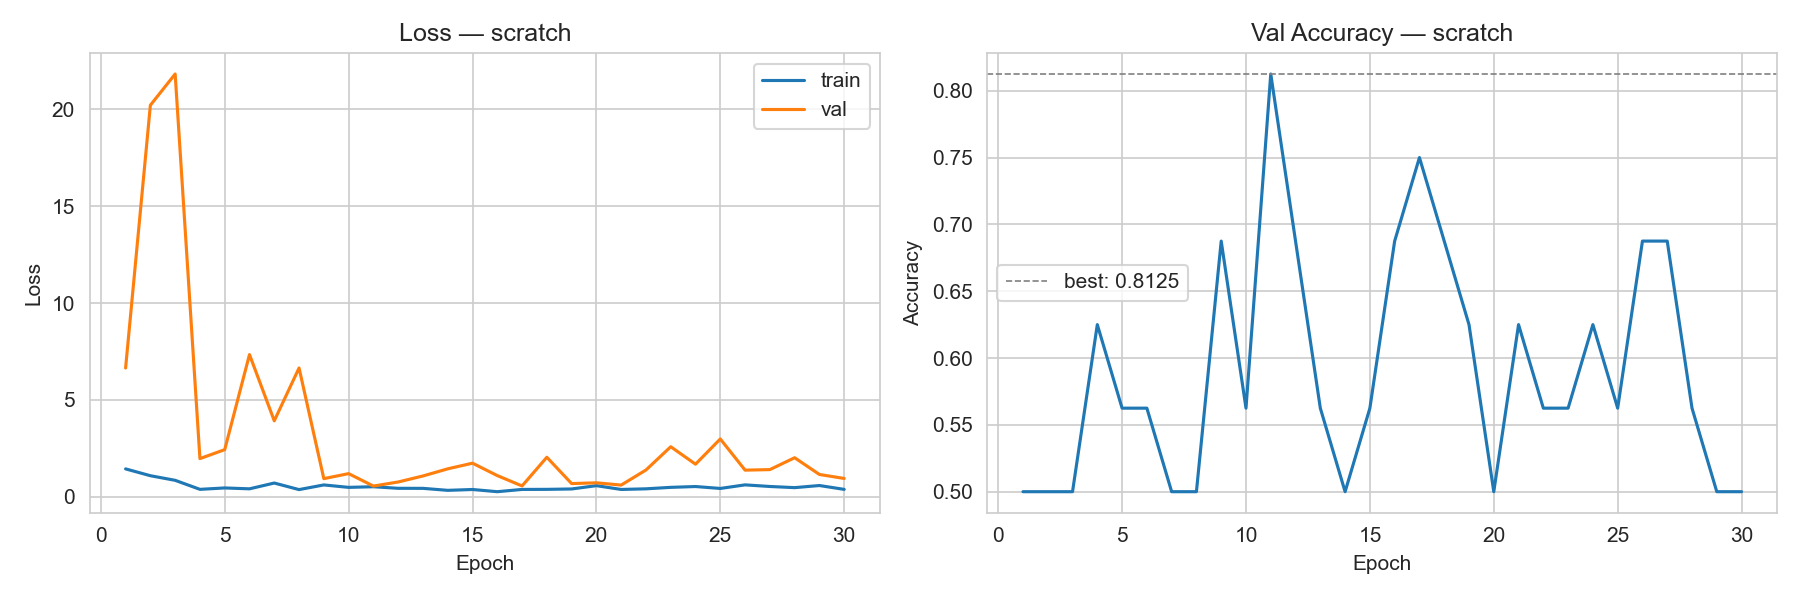

In [ ]:
for name in ("pretrained", "scratch"):
    with open(CHECKPOINTS / f"{name}_history.json") as f:
        h = json.load(f)
    best_ep  = h["val_acc"].index(max(h["val_acc"])) + 1
    best_acc = max(h["val_acc"])
    print(f"{name:12s}  best val_acc = {best_acc:.4f}  (epoch {best_ep}/{len(h['val_acc'])})")

print()
for name in ("pretrained", "scratch"):
    plot_learning_curves(name)
    display(Image(str(OUTPUTS / name / "learning_curves.png"), width=800))

## 4. Test Metrics

In [ ]:
loaders = get_loaders()
results = {}

for name in ("pretrained", "scratch"):
    model                   = load_model(name, device)
    y_true, y_pred, y_prob  = get_predictions(model, loaders["test"], device)
    metrics                 = compute_metrics(y_true, y_pred, y_prob)
    val_stats               = compute_val_stats(name)
    results[name] = dict(
        model=model, y_true=y_true, y_pred=y_pred, y_prob=y_prob,
        metrics=metrics, val_stats=val_stats,
    )

df = (
    pd.DataFrame({n: d["metrics"] for n, d in results.items()})
    .T.rename_axis("model")
)
display(df.style.format("{:.4f}").highlight_max(axis=0, props="font-weight: bold"))

# val accuracy summary
val_df = pd.DataFrame({n: d["val_stats"] for n, d in results.items()}).T.rename_axis("model")
display(val_df.style.format("{:.4f}"))

## 5. Confusion Matrices

In [ ]:
for name, data in results.items():
    plot_confusion_matrix(data["y_true"], data["y_pred"], name)
    display(Image(str(OUTPUTS / name / "confusion_matrix.png"), width=380))

## 6. Grad-CAM Analysis

In [ ]:
for name, data in results.items():
    plot_grad_cam(data["model"], name, device)
    display(Image(str(OUTPUTS / name / "grad_cam.png"), width=800))

## 7. ROC Curves & Comparison Table

In [ ]:
## 8. Conclusion

## 7. Conclusion

In [7]:

pt = results["pretrained"]["metrics"]
sc = results["scratch"]["metrics"]

hypothesis_pretrained = pt["accuracy"] > 0.80
hypothesis_scratch    = sc["accuracy"] < pt["accuracy"]
confirmed = hypothesis_pretrained and hypothesis_scratch

print("=" * 60)
print(f"  CONCLUSION: {'HYPOTHESIS CONFIRMED' if confirmed else 'HYPOTHESIS NOT FULLY CONFIRMED'}")
print("=" * 60)
print(f"\n  Hypothesis targets:")
print(f"    pretrained  > 80% accuracy  ->  {pt['accuracy']:.1%}  {'[OK]' if hypothesis_pretrained else '[FAIL]'}")
print(f"    scratch     < pretrained    ->  {sc['accuracy']:.1%}  {'[OK]' if hypothesis_scratch    else '[FAIL]'}")
print(f"\n  {'Metric':12s}  {'Pretrained':>12s}  {'Scratch':>10s}  {'Delta':>8s}")
print(f"  {'-'*48}")
for metric in ("accuracy", "precision", "recall", "f1", "auc_roc"):
    p = pt[metric]
    s = sc[metric]
    print(f"  {metric:12s}  {p:12.4f}  {s:10.4f}  {p - s:+8.4f}")
print(f"\n  Test set: 624 images ({CLASSES[0]} vs {CLASSES[1]})")
print("=" * 60)


  CONCLUSION: HYPOTHESIS CONFIRMED

  Hypothesis targets:
    pretrained  > 80% accuracy  ->  84.6%  [OK]
    scratch     < pretrained    ->  76.8%  [OK]

  Metric          Pretrained     Scratch     Delta
  ------------------------------------------------
  accuracy            0.8462      0.7676   +0.0785
  precision           0.8362      0.7733   +0.0629
  recall              0.8538      0.7910   +0.0628
  f1                  0.8408      0.7651   +0.0758
  auc_roc             0.9251      0.8808   +0.0443

  Test set: 624 images (NORMAL vs PNEUMONIA)
